<a href="https://colab.research.google.com/github/kestrel677/UNSUPERVISED-MACHINE-LEARNING/blob/main/K_Means_Clustering77.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

In [ ]:
df = pd.read_csv("/content/Wholesale customers data.csv")

df.head()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


In [ ]:
df.shape

(440, 8)

In [ ]:
df.columns

Index(['Region', 'Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper',
       'Delicassen'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Region            440 non-null    int64
 1   Fresh             440 non-null    int64
 2   Milk              440 non-null    int64
 3   Grocery           440 non-null    int64
 4   Frozen            440 non-null    int64
 5   Detergents_Paper  440 non-null    int64
 6   Delicassen        440 non-null    int64
dtypes: int64(7)
memory usage: 24.2 KB


In [ ]:
df.isnull().sum()

,0
Region,0
Fresh,0
Milk,0
Grocery,0
Frozen,0
Detergents_Paper,0
Delicassen,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.describe()

,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
count,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000
mean,2.543182,12000.297727,5796.265909,7951.277273,3071.931818,2881.493182,1524.870455
std,0.774272,12647.328865,7380.377175,9503.162829,4854.673333,4767.854448,2820.105937
min,1.000000,3.000000,55.000000,3.000000,25.000000,3.000000,3.000000
25%,2.000000,3127.750000,1533.000000,2153.000000,742.250000,256.750000,408.250000
50%,3.000000,8504.000000,3627.000000,4755.500000,1526.000000,816.500000,965.500000
75%,3.000000,16933.750000,7190.250000,10655.750000,3554.250000,3922.000000,1820.250000
max,3.000000,112151.000000,73498.000000,92780.000000,60869.000000,40827.000000,47943.000000


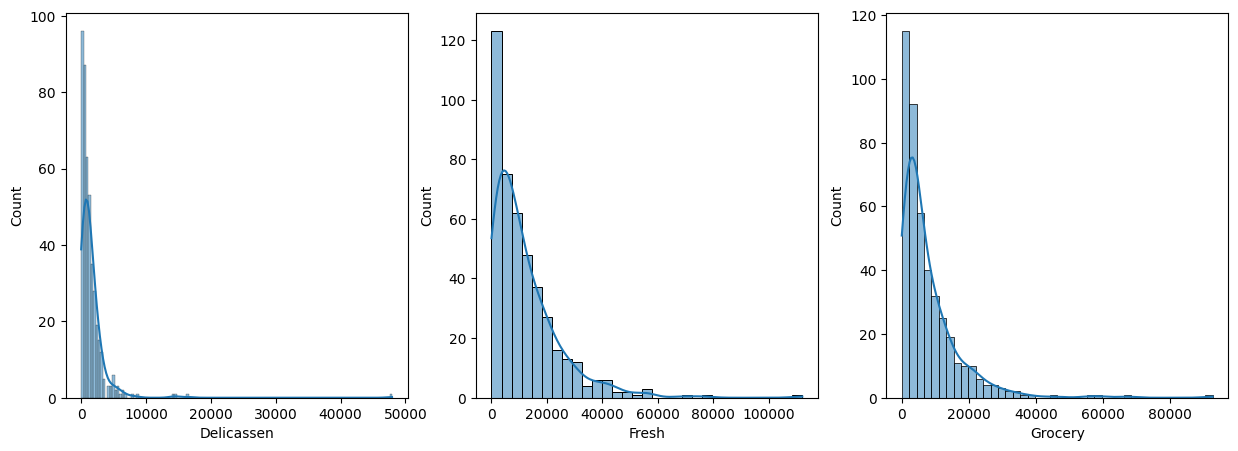

In [ ]:
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
sns.histplot(df['Delicassen'], kde=True)

plt.subplot(1,3,2)
sns.histplot(df['Fresh'], kde=True)

plt.subplot(1,3,3)
sns.histplot(df['Grocery'], kde=True)

plt.show()

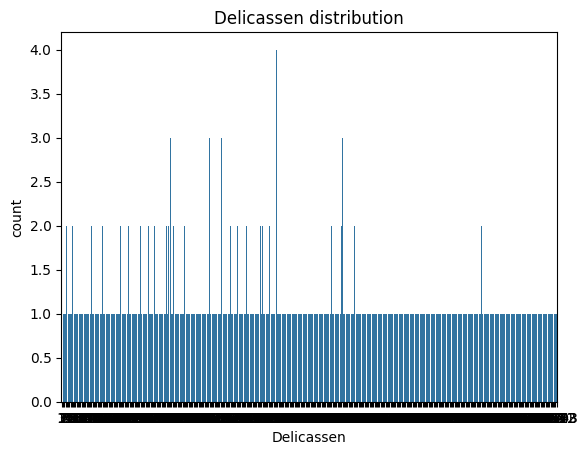

In [ ]:
sns.countplot(x='Delicassen', data=df)

plt.title("Delicassen distribution")

plt.show()

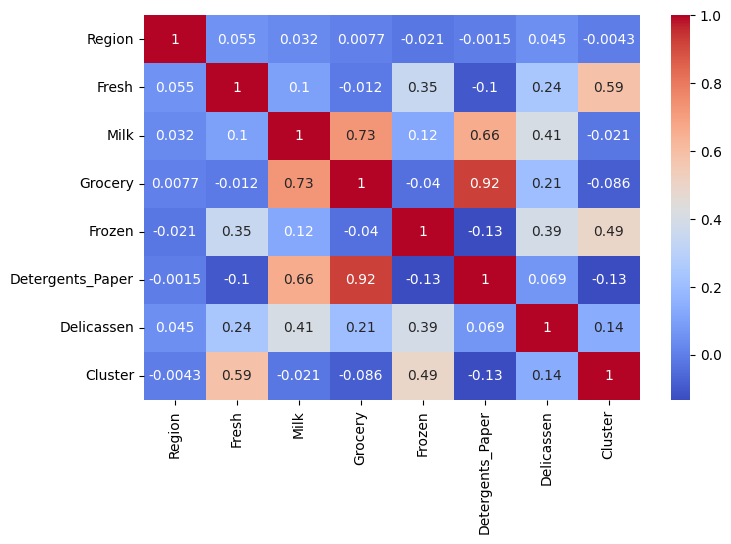

In [ ]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(8,5))

sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')

plt.show()

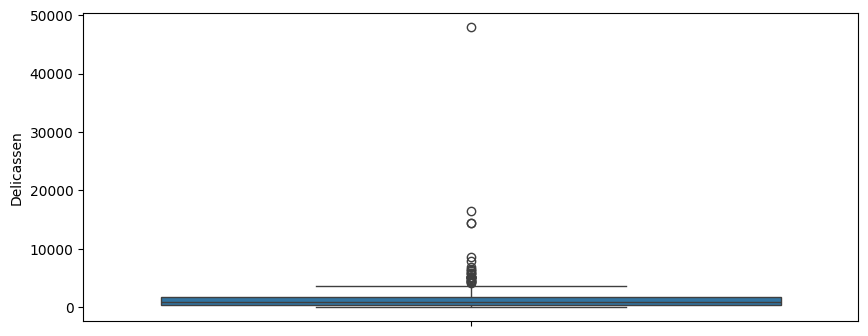

In [ ]:
plt.figure(figsize=(10,4))

sns.boxplot(df['Delicassen'])

plt.show()

In [ ]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(df)

In [ ]:
X_scaled[:5]

array([[ 0.59066829,  0.05293319,  0.52356777, -0.04111489, -0.58936716,
        -0.04356873, -0.06633906, -0.72583496],
       [ 0.59066829, -0.39130197,  0.54445767,  0.17031835, -0.27013618,
         0.08640684,  0.08915105, -0.72583496],
       [ 0.59066829, -0.44702926,  0.40853771, -0.0281571 , -0.13753572,
         0.13323164,  2.24329255, -0.72583496],
       [ 0.59066829,  0.10011141, -0.62401993, -0.3929769 ,  0.6871443 ,
        -0.49858822,  0.09341105,  2.0756333 ],
       [ 0.59066829,  0.84023948, -0.05239645, -0.07935618,  0.17385884,
        -0.23191782,  1.29934689,  1.51533965]])

In [ ]:
wcss = []

for i in range(1,11):

    km = KMeans(
        n_clusters=i,
        random_state=42
    )

    km.fit(X_scaled)

    wcss.append(km.inertia_)

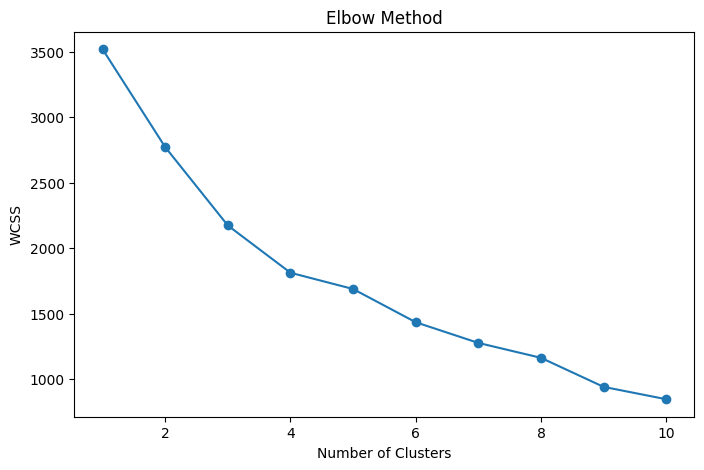

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(range(1,11), wcss, marker='o')

plt.xlabel("Number of Clusters")

plt.ylabel("WCSS")

plt.title("Elbow Method")

plt.show()

In [ ]:

km = KMeans(
    n_clusters=3,
    random_state=42
)

In [ ]:
y_means = km.fit_predict(X_scaled)

In [ ]:
df['Cluster'] = y_means

In [ ]:
df.head()

,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,Cluster
0,3,12669,9656,7561,214,2674,1338,0
1,3,7057,9810,9568,1762,3293,1776,0
2,3,6353,8808,7684,2405,3516,7844,0
3,3,13265,1196,4221,6404,507,1788,1
4,3,22615,5410,7198,3915,1777,5185,1


In [ ]:
cluster_profile = df.groupby('Cluster').mean()

cluster_profile

,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
Cluster,,,,,,,
0,2.460123,7251.119632,5241.211656,7620.168712,1741.285276,2835.156442,1180.328221
1,2.801980,25556.891089,3808.287129,4640.405941,6881.306931,844.752475,1818.930693
2,2.615385,25770.769231,35160.384615,41977.384615,6844.538462,19867.384615,7880.307692


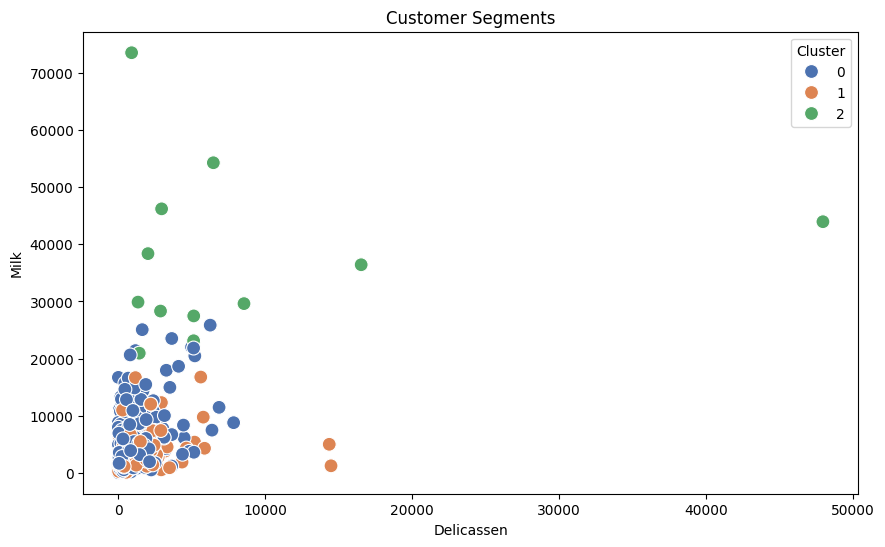

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

sns.scatterplot(
    x=df['Delicassen'],
    y=df['Milk'],
    hue=df['Cluster'],
    palette='deep',
    s=100
)

plt.title("Customer Segments")
plt.xlabel("Delicassen")
plt.ylabel("Milk")

plt.show()

In [ ]:
score = silhouette_score(X_scaled, y_means)

print("Silhouette Score:", score)

Silhouette Score: 0.38965222761085916


In [ ]:
for k in range(2,11):

    km = KMeans(
        n_clusters=k,
        random_state=42
    )

    labels = km.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, labels)

    print(f"K={k}, Score={score}")

K=2, Score=0.3728558802285021
K=3, Score=0.38965222761085916
K=4, Score=0.3640978591481179
K=5, Score=0.3573790766857755
K=6, Score=0.3656754681947021
K=7, Score=0.36739748539285905
K=8, Score=0.36834582486507733
K=9, Score=0.38625942314632805
K=10, Score=0.3531176302449872
